<a href="https://colab.research.google.com/github/diabateyoussouf/langgraph-agentic-workflows/blob/main/Projet03_Agent_Belvedere_Hotel/Projet03_Agent_Belvedere_Hotel/Projet03_Agent_Belvedere_Hotel/Projet03_Agent_Belvedere_Hotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objectif** :

Ton téléphone affiche un numéro inconnu. C'est Marc, le propriétaire de l'Hôtel Le Belvédère, au bord du lac d'Annecy. Léa lui a donné ton contact après lui avoir raconté l'histoire du Tour de France 2027. « J'ai un problème, et j'espère que tu peux m'aider », annonce-t-il d'une voix fatiguée. En pleine saison estivale, une bonne partie de son équipe de réception est clouée au lit par un virus qui tourne, et les deux personnes qui tiennent le comptoir croulent sous les appels et les emails : horaires d'arrivée, prix des chambres, présence d'un spa, chiens acceptés ou non, wifi... « On m'a parlé d'intelligence artificielle qui répond toute seule aux clients, un peu comme sur Booking. Ça t'intéresse de m'aider à mettre ça en place ? »

Tu acceptes, avec une condition posée par Marc lui-même : « Surtout, je ne veux pas qu'elle invente des choses. Imagine qu'elle promette un room service 24h/24 qu'on n'a pas, ou un tarif inventé, ça me retombe dessus. » Le problème est bien posé : un modèle de langage générique ne connaît rien de l'Hôtel Le Belvédère, il ne peut donc que deviner, ou pire, halluciner une réponse plausible mais fausse. La solution s'appelle le RAG (Retrieval-Augmented Generation) : donner au modèle un accès à la vraie documentation de l'hôtel, et lui interdire de répondre en dehors de ce qu'elle contient.

Dans ce projet, nous vaallons construire cet assistant pas à pas, en trois actes. D'abord, nous interrogerons un modèle de langage « tout nu », et nous le prendrons en flagrant délit d'invention. Ensuite, Marc nous enverra sa documentation, cinq fichiers PDF, que nous apprendrons à lire en Python et à glisser en entier dans le prompt : les réponses s'amélioreront nettement, mais pas complètement. Enfin, nous construirons un vrai RAG robuste, en orchestrant le flux d'informations avec LangGraph. Nous ne donnerons au modèle que les passages pertinents, des réponses justes, des sources citées, et un honnête « je ne sais pas » quand la documentation ne dit rien.

Pourquoi utiliser LangGraph ?
Pour répondre de manière fiable à Marc, un simple script linéaire ne suffit pas. Avec LangGraph, tu définiras des "états" et des "noeuds" (recherche, vérification, génération). Cela te permettra d'implémenter de la logique complexe : par exemple, vérifier si les documents trouvés sont vraiment pertinents avant d'essayer de générer une réponse, ou de recommencer la recherche si nécessaire. C'est la clé pour garantir à Marc que l'assistant se comporte de manière contrôlée, comme un vrai membre de l'équipe, et pas comme un script aléatoire.

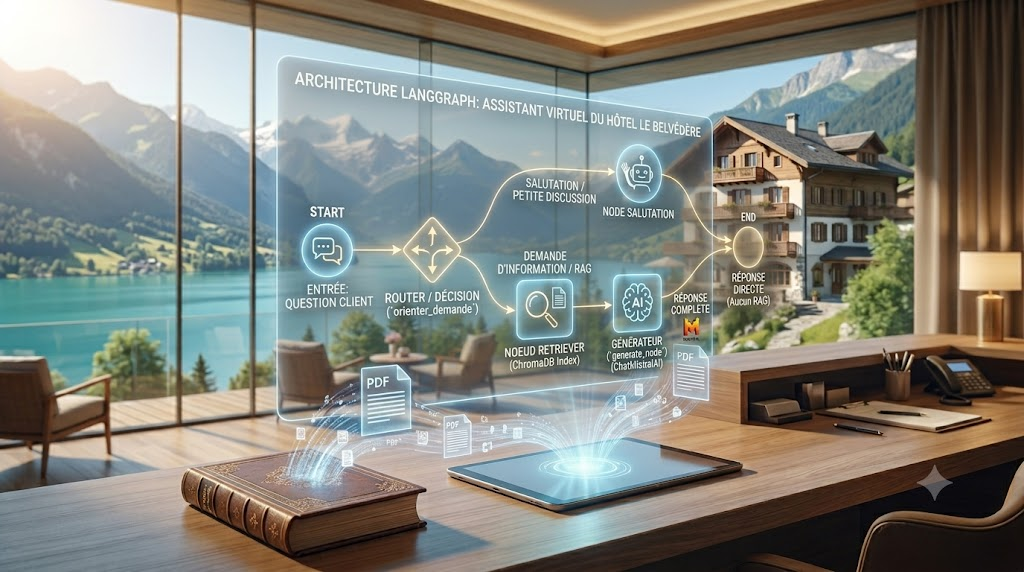

In [1]:
!pip install langchain-community langchain-core langchain-huggingface langchain-mistralai langchain-text-splitters langgraph langchain-chroma chromadb pydantic python-dotenv pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/7

# **Les imports**

In [39]:
import os
from typing import TypedDict, Literal,List,Optional, Dict, Any,Annotated

from langchain_community.document_loaders import PyPDFDirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage, SystemMessage,AIMessage,BaseMessage
from langgraph.graph import StateGraph, END,START
import chromadb
import os
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import NotRequired
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

# Importer les documents pour le RAG

In [11]:
path_pdfs = "/content/data"
loader = PyPDFDirectoryLoader(path_pdfs)

tokens = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ".", "!", "?", ",", " ", ""]
)

documents = loader.load_and_split(tokens)
print(f"Le nombre de documents : {len(documents)}")

Le nombre de documents : 16


### Le modèle embedding

In [12]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [13]:
persist_dir = "hotel/vectorStore"
chroma_client = chromadb.PersistentClient(path=persist_dir)

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="hotel_docs",
    client=chroma_client
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

print(f"✅ Base vectorielle ChromaDB indexée avec succès dans {persist_dir} !")

✅ Base vectorielle ChromaDB indexée avec succès dans hotel/vectorStore !


Tester le RAG sans llm

In [15]:
docs = retriever.invoke("A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?")

# Afficher les passages trouvés avec leurs sources
for i, doc in enumerate(docs, 1):
    print(f"--- Document {i} (Source : {doc.metadata.get('source', 'inconnue')}) ---")
    print(doc.page_content)
    print()

--- Document 1 (Source : /content/data/informations_pratiques.pdf) ---
Horaires de la réception
La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h. En dehors de ces horaires, un
numéro d'astreinte est affiché à l'entrée pour toute urgence. Le check-in démarre à 15h et le check-out se fait
avant 11h. Un départ tardif jusqu'à 13h peut être accordé gratuitement selon la disponibilité des chambres, il
suffit de le demander la veille à la réception. Une arrivée tardive après 22h doit être annoncée à l'avance par
téléphone ou email pour que le personnel de nuit prépare la remise des clés.
Hôtel Le Belvédère - 12 avenue du Lac, 74000 Annecy - Documentation interne - page 1

--- Document 2 (Source : /content/data/chambres_et_tarifs.pdf) ---
gratuitement sur demande, un lit d'appoint pour un enfant ou un adulte supplémentaire coûte 25 euros par
nuit. Le petit-déjeuner n'est pas inclus dans le tarif de base, il coûte 18 euros par personne en supplément,
sauf pour le tari

## Créer un llm

In [16]:
from google.colab import userdata
key = userdata.get('generate_key')

llm = ChatMistralAI(
    model="mistral-small-latest",
    temperature=0.0,
    api_key=key,
    verbose=True
)

In [19]:
# tester llm
print(llm.invoke("Bonjour comment vas-tu ?"))
print("="*60)
print(llm.invoke("A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?"))

content="Bonjour ! 😊 Je vais très bien, merci de demander ! Et toi, comment vas-tu aujourd'hui ? Je suis là pour t'aider ou discuter si tu en as envie. 💬✨\n\n(Et si tu veux, tu peux aussi me dire ce que tu cherches ou poser une question !)" additional_kwargs={} response_metadata={'token_usage': {'prompt_tokens': 21, 'total_tokens': 90, 'completion_tokens': 69, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small-latest', 'model': 'mistral-small-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'} id='lc_run--019fa44f-a3de-7fb0-89af-ac02d9dd82e0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 21, 'output_tokens': 69, 'total_tokens': 90}
content="Pour connaître les horaires de **check-in** à l'**Hôtel Le Belvédère**, je vous recommande de consulter directement leur site officiel ou de les contacter par téléphone ou email. Voici les informations générales que je peux vous fournir :\n\n### **Horaires de check-in typiques** (à confi

Donc un llm simple ne connît pas les informations pertinentes de l'hotel, il faut donc lui fournir pourqu'il puisse apprendre.

# Créer L'état initial de langgraph

In [40]:
class RAGState(TypedDict):
    question: str
    top_k: int
    retrieved_docs: List[Dict[str, Any]]
    context: str
    answer: str
    messages: Annotated[list[BaseMessage], add_messages]

In [41]:
# exemple d'initialisation
agent = RAGState({
    "question": "A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?",
    "top_k": 4,
    "retrieved_docs": [],
    "context": "",
    "answer": ""
})

In [42]:
agent["question"]

"A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?"

### Les noeuds

In [43]:
def noeud_retriever(state: RAGState) -> dict:
    question = state["question"]
    messages = state.get("messages", [])

    # S'il y a déjà eu une discussion avant, on reformule la question avec le contexte
    if len(messages) > 1:
        prompt_reformulation = f"""
        Voici l'historique d'une conversation avec un client :{messages[:-1]}
        Dernière question du client : {question}
        Reformule cette dernière question pour qu'elle soit autonome et compréhensible sans l'historique (ex: remplace 'elles' par 'les chambres Supérieures').
        Donne UNIQUEMENT la question reformulée :
        """

        question_pour_search = llm.invoke(prompt_reformulation).content.strip()
    else:
        question_pour_search = question

    # Recherche vectorielle avec la question autonome
    docs = retriever.invoke(question_pour_search)

    return {
        "retrieved_docs": docs,
        "messages": [HumanMessage(content=question)]  # On enregistre le message client
    }

In [44]:
# tester
print(noeud_retriever(agent))

{'retrieved_docs': [Document(metadata={'source': '/content/data/informations_pratiques.pdf', 'page_label': '1', 'total_pages': 4, 'title': 'Informations Pratiques', 'author': 'Hôtel Le Belvédère', 'creator': 'PyPDF', 'producer': 'PyPDF', 'page': 0, 'creationdate': '2026-07-23T12:06:10+00:00'}, page_content="Horaires de la réception\nLa réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h. En dehors de ces horaires, un\nnuméro d'astreinte est affiché à l'entrée pour toute urgence. Le check-in démarre à 15h et le check-out se fait\navant 11h. Un départ tardif jusqu'à 13h peut être accordé gratuitement selon la disponibilité des chambres, il\nsuffit de le demander la veille à la réception. Une arrivée tardive après 22h doit être annoncée à l'avance par\ntéléphone ou email pour que le personnel de nuit prépare la remise des clés.\nHôtel Le Belvédère - 12 avenue du Lac, 74000 Annecy - Documentation interne - page 1"), Document(metadata={'page': 0, 'title': 'Chambres Et T

In [45]:
def generate_node(state: RAGState) -> dict:
    """ Le noued qui permet de generer une reponse avc llm  """
    docs = state["retrieved_docs"]
    context = "\n\n".join([doc.page_content for doc in docs])

    role = (
        "Tu es l'assistant virtuel de l'Hôtel Le Belvédère, au bord du lac d'Annecy.\n"
        "Voici la documentation officielle de l'hôtel :"
    )
    consigne = (
        "Réponds en une ou deux phrases, uniquement à partir des informations "
        "de la documentation ci-dessus. Si l'information ne s'y trouve pas, réponds exactement : "
        '"Je ne sais pas, je vous invite à contacter la réception."'
    )

    prompt = f"{role}\n\n{context}\n\nQuestion d'un client : {state['question']}\n{consigne}"
    response = llm.invoke(prompt)
    answer = response.content

    return {
        "context": context,
        "answer": answer,
        "messages": [AIMessage(content=answer)]  # On enregistre la réponse de l'IA
    }

In [46]:
print(generate_node(agent))

{'context': '', 'answer': 'Vous pouvez effectuer votre check-in à partir de 14h00.', 'messages': [AIMessage(content='Vous pouvez effectuer votre check-in à partir de 14h00.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


In [47]:
def node_salutation(state: RAGState) -> dict:
    answer = "Bonjour ! Je vais très bien, merci. Je suis l'assistant virtuel de l'Hôtel Le Belvédère. Comment puis-je vous aider aujourd'hui ?"
    return {
        "answer": answer,
        "messages": [
            HumanMessage(content=state["question"]),
            AIMessage(content=answer)
        ]
    }

### Les routeurs

In [48]:
def orienter_demande(state: RAGState) -> str:
    """Détermine si on doit interroger la base documentaire ou répondre directement."""
    question = state["question"].lower().strip()

    # Salutations simples
    salutations = ["bonjour", "bonsoir", "salut", "hello", "coucou"]
    if question in salutations or len(question.split()) <= 2 and any(w in question for w in salutations):
        return "repondre_salutation"

    # Sinon, recherche RAG standard
    return "retriever"

## construction de graph

In [49]:
workflow = StateGraph(RAGState)

# Ajout des nœuds
workflow.add_node("retriever", noeud_retriever)
workflow.add_node("generator", generate_node)
workflow.add_node("salutation", node_salutation)

# Routeur
workflow.add_conditional_edges(
    START,
    orienter_demande,
    {
        "repondre_salutation": "salutation",
        "retriever": "retriever"
    }
)

workflow.add_edge("salutation", END)
workflow.add_edge("retriever", "generator")
workflow.add_edge("generator", END)

# Création du checkpointer de mémoire en mémoire vive
memory = MemorySaver()

# Compilation avec le checkpointer
app = workflow.compile(checkpointer=memory)

In [50]:
from IPython.display import display, Image

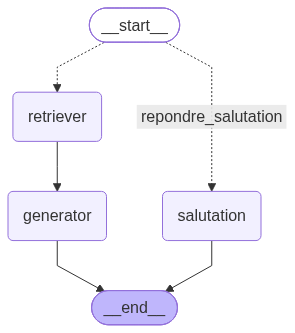

In [51]:
display(Image(app.get_graph().draw_mermaid_png()))

In [53]:
questions_hotel = [
    "Bonjour comment vous allez ?",
    "A quelle heure commence le check-in ?",
    "Le wifi est-il gratuit ?",
    "Combien coute une chambre Classique en basse saison ?",
    "Est-ce que vous acceptez les paiements en Bitcoin ?",
]

print("=== 🏨 TEST DU GRAPH LANGGRAPH HÔTEL LE BELVÉDÈRE ===\n")

for i, question in enumerate(questions_hotel, 1):
    print(f"📌 [{i}] Question : {question}")

    # Configuration obligatoire avec un thread_id propre à chaque question
    config = {"configurable": {"thread_id": f"test_session_{i}"}}

    # Exécution du graphe
    resultat = app.invoke({"question": question}, config=config)

    # Affichage
    print(f"🤖 Réponse  : {resultat['answer']}")
    print("-" * 65)

=== 🏨 TEST DU GRAPH LANGGRAPH HÔTEL LE BELVÉDÈRE ===

📌 [1] Question : Bonjour comment vous allez ?
🤖 Réponse  : Bonjour, je vais très bien, merci ! Et vous, comment allez-vous ?
-----------------------------------------------------------------
📌 [2] Question : A quelle heure commence le check-in ?
🤖 Réponse  : Le check-in commence à 15h.
-----------------------------------------------------------------
📌 [3] Question : Le wifi est-il gratuit ?
🤖 Réponse  : Oui, le wifi est gratuit et illimité dans toutes les chambres ainsi que dans les parties communes de l'hôtel.
-----------------------------------------------------------------
📌 [4] Question : Combien coute une chambre Classique en basse saison ?
🤖 Réponse  : Une chambre Classique coûte **120 euros la nuit** en basse saison.
-----------------------------------------------------------------
📌 [5] Question : Est-ce que vous acceptez les paiements en Bitcoin ?
🤖 Réponse  : Je ne sais pas, je vous invite à contacter la réception.
------

In [54]:
#  On fixe un SEUL et MÊME thread_id pour toute la conversation
config_session = {"configurable": {"thread_id": "session_test_memoire_001"}}

# Scénario de dialogue où chaque question dépend de la précédente
dialogue_suivi = [
    "Avez-vous des chambres avec balcon ?",               # Contexte initial
    "Combien coûtent-elles en haute saison ?",             # "elles" = chambres avec balcon
    "Le petit-déjeuner est-il inclus dans ce tarif ?"     # "ce tarif" = prix haute saison balcon
]

print("=== 🧪 TEST DE LA MÉMOIRE (FIL DE DISCUSSION UNIQUE) ===\n")

for tour, question in enumerate(dialogue_suivi, 1):
    print(f"👤 Tour {tour} - Client : {question}")

    # Exécution avec la même configuration de session
    resultat = app.invoke({"question": question}, config=config_session)

    print(f"🤖 Agent          : {resultat['answer']}")
    print("=" * 65)

=== 🧪 TEST DE LA MÉMOIRE (FIL DE DISCUSSION UNIQUE) ===

👤 Tour 1 - Client : Avez-vous des chambres avec balcon ?
🤖 Agent          : Oui, les chambres **Supérieure** disposent d'un petit balcon avec vue partielle sur le lac.
👤 Tour 2 - Client : Combien coûtent-elles en haute saison ?
🤖 Agent          : En haute saison, les chambres coûtent :
- Classique : 150 €/nuit
- Supérieure : 190 €/nuit
- Deluxe Vue Lac : 260 €/nuit
- Suite Belvédère : 420 €/nuit.
👤 Tour 3 - Client : Le petit-déjeuner est-il inclus dans ce tarif ?
🤖 Agent          : Le petit-déjeuner n'est pas inclus dans le tarif de base, sauf pour le tarif Flexible qui l'inclut déjà.


In [55]:
!pip install -q gradio

In [56]:
import gradio as gr

def repondre_chat(message, history):
    # On utilise un thread_id unique pour la session de test
    config = {"configurable": {"thread_id": "session_gradio_demo"}}

    # Exécution de ton graphe LangGraph
    resultat = app.invoke({"question": message}, config=config)
    return resultat["answer"]

# Création de l'interface de Chat
demo = gr.ChatInterface(
    fn=repondre_chat,
    title="🏨 Hôtel Le Belvédère - Concierge Virtuel",
    description="Posez vos questions sur l'hôtel, le SPA, les tarifs et les services.",
    textbox=gr.Textbox(placeholder="Posez votre question ici...", container=False, scale=7),
)

# share=True génère l'URL publique accessible par n'importe qui !
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f15a89e0234b5387c2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


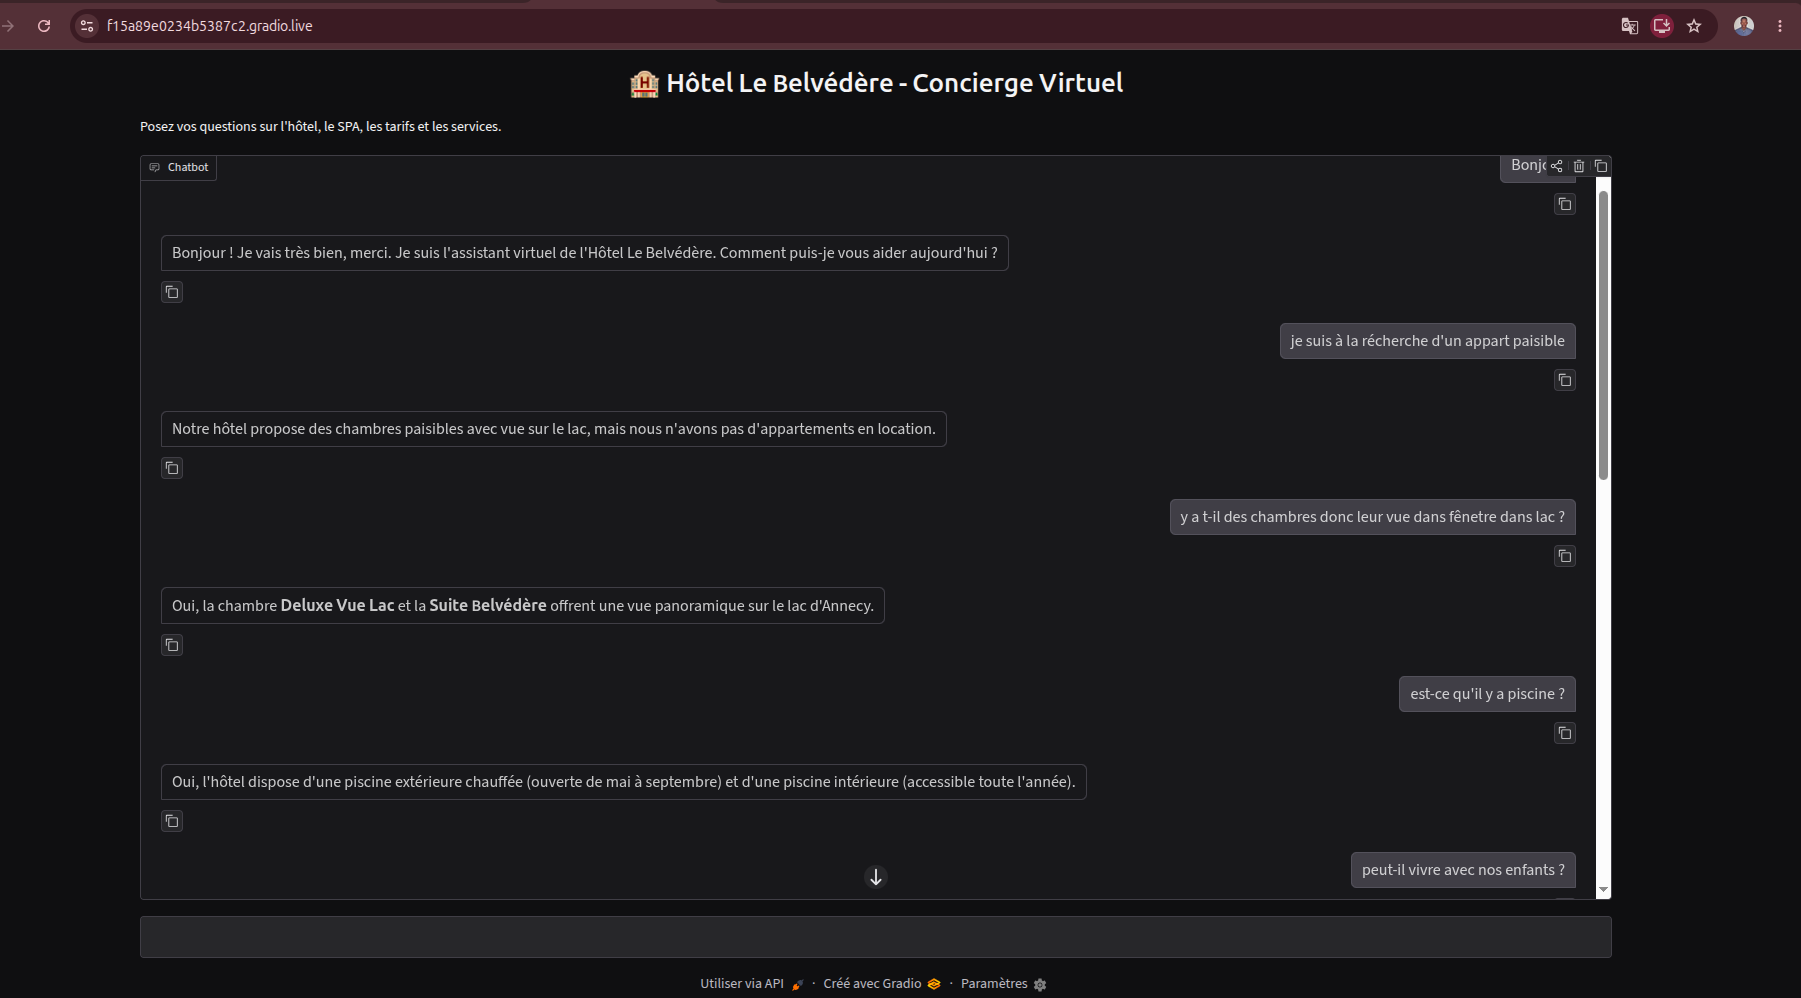